# Exam Fall 2023


In [1]:
# Remove warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots 
import matplotlib.pyplot as plt
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import ModelSpec as MS

from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from sklearn.metrics import (accuracy_score,
                             log_loss)
from sklearn.ensemble import \
     (RandomForestRegressor as RF,
      GradientBoostingRegressor as GBR)
from ISLP.bart import BART


## 1. Predict main variable explaining being a client and take up 

In [70]:
data = pd.read_csv(
    'C:/Users/jdnmiguel/Dropbox/Teaching/Machine Learning/replication/exam.csv'
)

In [71]:
model = data.drop(columns=['client', 'treatment', 'aloansamt_alamana', 'profit_total'])
model = MS(model.columns, intercept=False)
D = model.fit_transform(data)
feature_names = list(D.columns)
X = np.asarray(D)
y = data.client.values

### Being a client
#### a. Random Forest

In [72]:
(X_train,
 X_test,
 y_train,
 y_test) = skm.train_test_split(X,
                                   y,
                                   test_size=0.3,
                                   random_state=181223)

In [73]:
RF_maroc = RF(max_features=9,
               random_state=181223).fit(X_train, y_train)
y_hat_RF = RF_maroc.predict(X_test)
np.mean((y_test - y_hat_RF)**2)


0.07110882171499075

Test MSE is 0.07

In [74]:
feature_imp = pd.DataFrame(
    {'importance':RF_maroc.feature_importances_},
    index=feature_names)
feature_imp.sort_values(by='importance', ascending=False)

,importance
head_age,0.034793
consumption_pc,0.032040
consumption,0.032002
assets_total,0.029682
id3,0.029296
...,...
selfempl_business,0.001914
selfempl_livestock,0.001761
self_empl,0.001704
head_male,0.001464


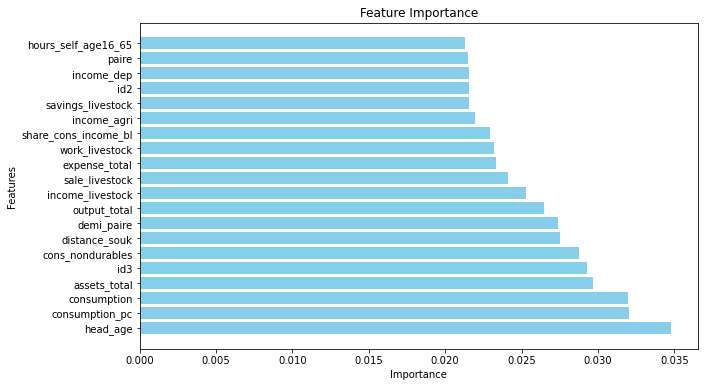

In [77]:
# Sort the 20 most importance feature  in descending order
top_20_features = feature_imp_sorted.head(20)
feature_imp_sorted = top_20_features.sort_values(by='importance', ascending=False)

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_sorted.index, feature_imp_sorted['importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.show()

#### B. Boosting

In [78]:
boost_maroc = GBR(n_estimators=5000,
                   learning_rate=0.001,
                   max_depth=3,
                   random_state=0)
boost_maroc.fit(X_train, y_train)


GradientBoostingRegressor(learning_rate=0.001, n_estimators=5000,
                          random_state=0)

In [79]:
y_hat_boost = boost_maroc.predict(X_test);
np.mean((y_test - y_hat_boost)**2)

0.07187722717412368

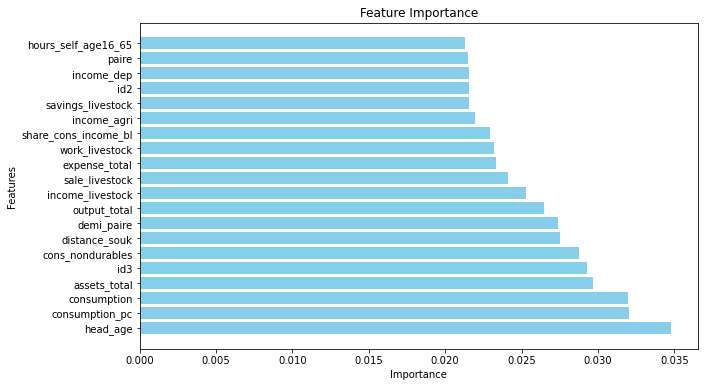

In [80]:
feature_imp_b = pd.DataFrame(
    {'importance':boost_maroc.feature_importances_},
    index=feature_names)
feature_imp.sort_values(by='importance', ascending=False)


# Sort the 20 most importance feature  in descending order
top_20_features_b = feature_imp.head(20)
feature_imp_sorted_b = top_20_features_b.sort_values(by='importance', ascending=False)

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_sorted.index, feature_imp_sorted['importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.show()


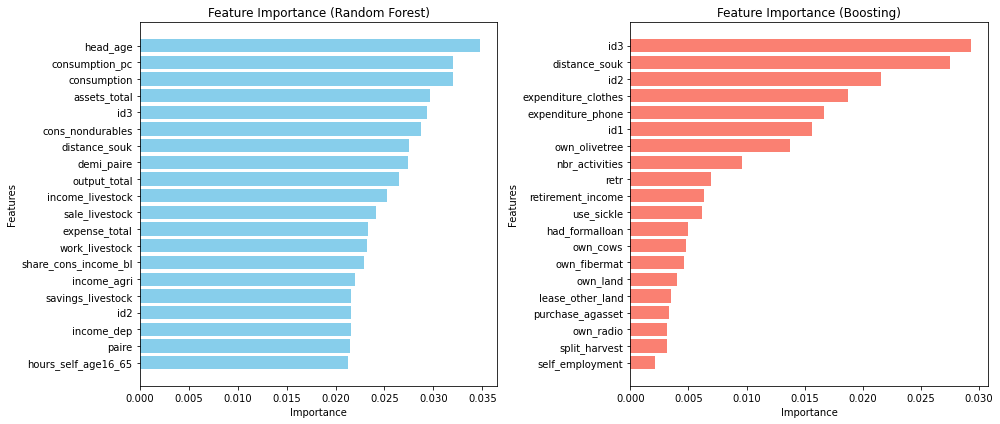

In [81]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot the first graph on the first subplot (left)
ax1.barh(feature_imp_sorted.index, feature_imp_sorted['importance'], color='skyblue')
ax1.set_xlabel('Importance')
ax1.set_ylabel('Features')
ax1.set_title('Feature Importance (Random Forest)')
ax1.invert_yaxis()  # Invert the y-axis to display the most important feature at the top

# Assuming you have another DataFrame called 'feature_imp2' for the second graph
# Plot the second graph on the second subplot (right)
ax2.barh(feature_imp_sorted_b.index, feature_imp_sorted_b['importance'], color='salmon')
ax2.set_xlabel('Importance')
ax2.set_ylabel('Features')
ax2.set_title('Feature Importance (Boosting)')
ax2.invert_yaxis()  # Invert the y-axis to display the most important feature at the top

# Adjust the space between subplots
plt.tight_layout()

# Show the combined subplots
plt.show()


### Amount Borrowed

In [82]:
y = data.aloansamt_alamana.values

In [83]:
(X_train,
 X_test,
 y_train,
 y_test) = skm.train_test_split(X,
                                   y,
                                   test_size=0.3,
                                   random_state=181223)
RF_maroc = RF(max_features=9,
               random_state=181223).fit(X_train, y_train)
y_hat_RF = RF_maroc.predict(X_test)
np.mean((y_test - y_hat_RF)**2)


9600382.967717458

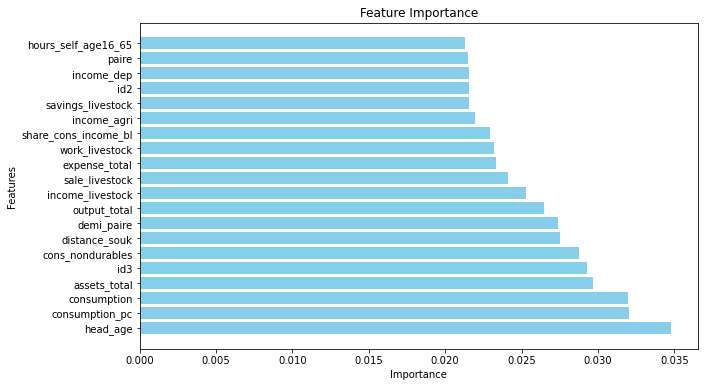

In [85]:
feature_imp = pd.DataFrame(
    {'importance':RF_maroc.feature_importances_},
    index=feature_names)
feature_imp.sort_values(by='importance', ascending=False)

# Sort the 20 most importance feature  in descending order
top_20_features = feature_imp_sorted.head(20)
feature_imp_sorted = top_20_features.sort_values(by='importance', ascending=False)

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_sorted.index, feature_imp_sorted['importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.show()

#### Boosting 

In [86]:
boost_maroc = GBR(n_estimators=500,
                   learning_rate=0.001,
                   max_depth=3,
                   random_state=0)
boost_maroc.fit(X_train, y_train)


GradientBoostingRegressor(learning_rate=0.001, n_estimators=500, random_state=0)

In [87]:
y_hat_boost = boost_maroc.predict(X_test);
np.mean((y_test - y_hat_boost)**2)

9781112.886249715

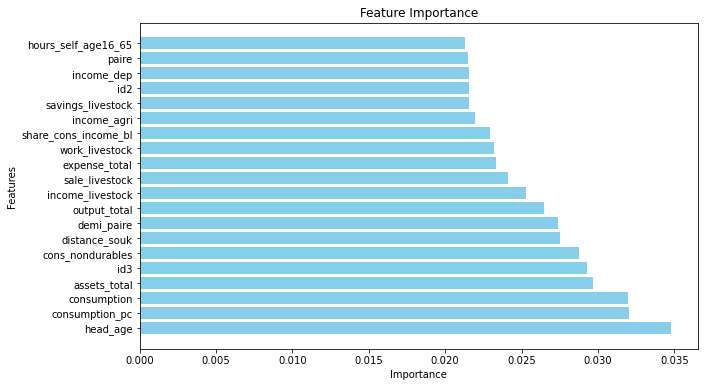

In [88]:
feature_imp_b = pd.DataFrame(
    {'importance':boost_maroc.feature_importances_},
    index=feature_names)
feature_imp.sort_values(by='importance', ascending=False)


# Sort the 20 most importance feature  in descending order
top_20_features_b = feature_imp.head(20)
feature_imp_sorted_b = top_20_features_b.sort_values(by='importance', ascending=False)

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_sorted.index, feature_imp_sorted['importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.show()

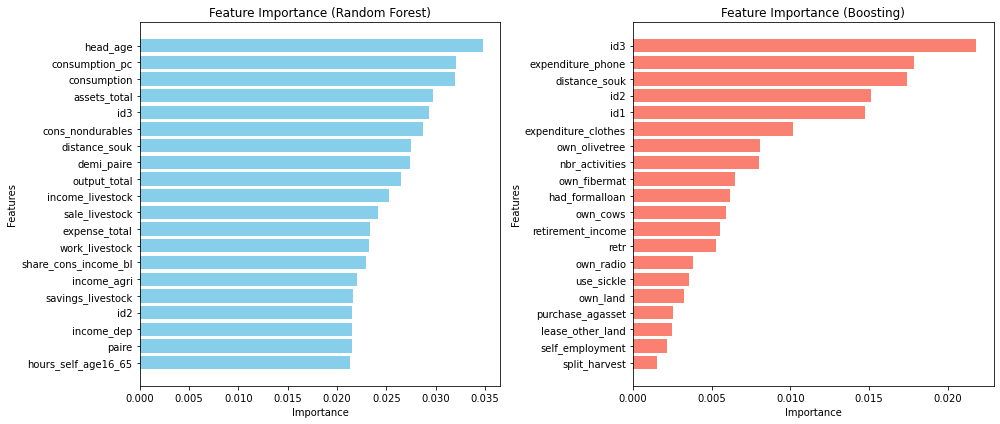

In [89]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot the first graph on the first subplot (left)
ax1.barh(feature_imp_sorted.index, feature_imp_sorted['importance'], color='skyblue')
ax1.set_xlabel('Importance')
ax1.set_ylabel('Features')
ax1.set_title('Feature Importance (Random Forest)')
ax1.invert_yaxis()  # Invert the y-axis to display the most important feature at the top

# Assuming you have another DataFrame called 'feature_imp2' for the second graph
# Plot the second graph on the second subplot (right)
ax2.barh(feature_imp_sorted_b.index, feature_imp_sorted_b['importance'], color='salmon')
ax2.set_xlabel('Importance')
ax2.set_ylabel('Features')
ax2.set_title('Feature Importance (Boosting)')
ax2.invert_yaxis()  # Invert the y-axis to display the most important feature at the top

# Adjust the space between subplots
plt.tight_layout()

# Show the combined subplots
plt.show()

## Estimate treatment effect 

In [99]:
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn.model_selection import KFold
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
# Import everything
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm

from numpy.linalg import inv
from statsmodels.iolib.summary2 import summary_col
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

### PDS LASSO 

In [96]:
data['const'] = 1
y_c = data['client']
y_p = data['profit_total']
y_b = data['aloansamt_alamana']
d =data[['const', 'treatment']]

# Estimate an OLS regression for each outcome
reg1 = sm.OLS(y_c, d, missing='drop').fit()
reg2 = sm.OLS(y_p, d, missing='drop').fit()
reg3 = sm.OLS(y_b, d, missing='drop').fit()


In [97]:
# Make table 
def make_table():

    info_dict={'No. observations' : lambda x: f"{int(x.nobs):d}"}

    results_table = summary_col(results=[reg1,reg2,reg3],
                                float_format='%0.2f',
                                stars = True,
                                model_names=['Model 1','Model 2','Model 3'],
                                info_dict=info_dict,
                                regressor_order=['const','treatment'])
    return results_table

In [100]:
table = make_table()
table

,Model 1,Model 2,Model 3
const,0.00,9024.27***,138.48***
,(0.00),(907.54),(46.16)
treatment,0.16***,2038.29,561.61***
,(0.01),(1290.29),(65.63)
R-squared,0.09,0.00,0.01
R-squared Adj.,0.09,0.00,0.01
No. observations,5401,5401,5401


In [104]:
X = D 

1. Lasso the outcome on x 
2. Lasso the treatment on x
3. form the union of controls

In [105]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X)
X = pd.DataFrame(data=scaler.transform(X),columns = X.columns)

lassoyc = linear_model.LassoCV(max_iter=1000).fit(X, y_c)
lassoyp = linear_model.LassoCV(max_iter=1000).fit(X, y_p)
lassoyb = linear_model.LassoCV(max_iter=1000).fit(X, y_b)

In [107]:
d =data[['treatment']]
lassod = linear_model.LassoCV(max_iter=1000).fit(X, d)

In [109]:
Xunionc=X.iloc[:,(lassod.coef_!=0) + (lassoyc.coef_!=0)]
Xunionb=X.iloc[:,(lassod.coef_!=0) + (lassoyp.coef_!=0)]
Xunionp=X.iloc[:,(lassod.coef_!=0) + (lassoyb.coef_!=0)]

In [111]:
# Make sure to reset the index to avoid duplicate values
d = d.reset_index(drop=True)
Xunionc = Xunionc.reset_index(drop=True)
Xunionp = Xunionp.reset_index(drop=True)
Xunionb = Xunionb.reset_index(drop=True)
y_c = y_c.reset_index(drop=True)
y_p = y_p.reset_index(drop=True)
y_b = y_b.reset_index(drop=True)

# Concatenate DataFrames
rhs_c = pd.concat([d, Xunionc], axis=1)
rhs_p = pd.concat([d, Xunionp], axis=1)
rhs_b = pd.concat([d, Xunionb], axis=1)

# Estimate an OLS regression for each outcome
reg1 = sm.OLS(y_c, rhs_c, missing='drop').fit()
reg2 = sm.OLS(y_p, rhs_p, missing='drop').fit()
reg3 = sm.OLS(y_b, rhs_b, missing='drop').fit()

In [112]:
# Make table 
def make_table():

    info_dict={'No. observations' : lambda x: f"{int(x.nobs):d}"}

    results_table = summary_col(results=[reg1,reg2,reg3],
                                float_format='%0.2f',
                                stars = True,
                                model_names=['Model 1','Model 2','Model 3'],
                                info_dict=info_dict,
                                regressor_order=['treatment'])
    return results_table

In [113]:
table = make_table()
table

,Model 1,Model 2,Model 3
treatment,0.16***,20279.34***,841.51***
,(0.01),(0.00),(64.91)
inv_livestock,0.01,0.00***,10.17
,(0.00),(0.00),(43.03)
pact2,-0.00,0.00,50.30
,(0.00),(0.00),(36.39)
sale_agri,-0.00,21484.36***,2656386236.73
,(0.00),(371.73),(10936102897.82)
retr,0.01***,-0.00***,-52.59
,(0.00),(0.00),(574.08)


### DDML 

In [114]:
y = data['client']

In [116]:
# import random forest
from sklearn.ensemble import RandomForestRegressor
# instantiate random forest objects
rfy=RandomForestRegressor(n_estimators=100)
rfd = rfy

# create our sample splitting "object"
kf = KFold(n_splits=5,shuffle=True,random_state=42)

# apply the splits to our Xs
kf.get_n_splits(X)


# initialize columns for residuals
yresidrf = y*0
dresidrf = d*0

# Now loop through each fold
for train_index, test_index in kf.split(X):
  X_train, X_test = X.iloc[train_index,:], X.iloc[test_index,:]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]
  d_train, d_test = d.iloc[train_index,:], d.iloc[test_index,:]

  # Do DML thing
  # Ridge y on training folds:
  rfy.fit(X_train, y_train)

  # but get residuals in test set
  yresidrf.iloc[test_index]=y_test-rfy.predict(X_test)

  #Ridge d on training folds
  rfd.fit(X_train, d_train)
  #but get residuals in test set
  dresidrf.iloc[test_index,:]=d_test-rfd.predict(X_test).reshape(-1,1)


# Regress resids
dmlreg=linear_model.LinearRegression().fit(dresidrf,yresidrf)

rhs = sm.add_constant(dresidrf)
model = sm.OLS(yresidrf, rhs)
results = model.fit(cov_type='HC3')
print(results.summary())

DML regression protection against expropriation effect on gdp: 0.314
                            OLS Regression Results                            
Dep. Variable:                 client   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     263.6
Date:                Mon, 18 Dec 2023   Prob (F-statistic):           6.38e-58
Time:                        11:33:14   Log-Likelihood:                -363.28
No. Observations:                5401   AIC:                             730.6
Df Residuals:                    5399   BIC:                             743.8
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

In [117]:
y = data['profit_total']

In [118]:
# instantiate random forest objects
rfy=RandomForestRegressor(n_estimators=100)
rfd = rfy

# create our sample splitting "object"
kf = KFold(n_splits=5,shuffle=True,random_state=42)

# apply the splits to our Xs
kf.get_n_splits(X)


# initialize columns for residuals
yresidrf = y*0
dresidrf = d*0

# Now loop through each fold
for train_index, test_index in kf.split(X):
  X_train, X_test = X.iloc[train_index,:], X.iloc[test_index,:]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]
  d_train, d_test = d.iloc[train_index,:], d.iloc[test_index,:]

  # Do DML thing
  # Ridge y on training folds:
  rfy.fit(X_train, y_train)

  # but get residuals in test set
  yresidrf.iloc[test_index]=y_test-rfy.predict(X_test)

  #Ridge d on training folds
  rfd.fit(X_train, d_train)
  #but get residuals in test set
  dresidrf.iloc[test_index,:]=d_test-rfd.predict(X_test).reshape(-1,1)


# Regress resids
dmlreg=linear_model.LinearRegression().fit(dresidrf,yresidrf)

rhs = sm.add_constant(dresidrf)
model = sm.OLS(yresidrf, rhs)
results = model.fit(cov_type='HC3')
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           profit_total   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.2834
Date:                Mon, 18 Dec 2023   Prob (F-statistic):              0.595
Time:                        11:37:13   Log-Likelihood:                -59130.
No. Observations:                5401   AIC:                         1.183e+05
Df Residuals:                    5399   BIC:                         1.183e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -45.5642    187.258     -0.243      0.8

In [119]:
y = data['aloansamt_alamana']

In [120]:
# import random forest
from sklearn.ensemble import RandomForestRegressor
# instantiate random forest objects
rfy=RandomForestRegressor(n_estimators=100)
rfd = rfy

# create our sample splitting "object"
kf = KFold(n_splits=5,shuffle=True,random_state=42)

# apply the splits to our Xs
kf.get_n_splits(X)


# initialize columns for residuals
yresidrf = y*0
dresidrf = d*0

# Now loop through each fold
for train_index, test_index in kf.split(X):
  X_train, X_test = X.iloc[train_index,:], X.iloc[test_index,:]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]
  d_train, d_test = d.iloc[train_index,:], d.iloc[test_index,:]

  # Do DML thing
  # Ridge y on training folds:
  rfy.fit(X_train, y_train)

  # but get residuals in test set
  yresidrf.iloc[test_index]=y_test-rfy.predict(X_test)

  #Ridge d on training folds
  rfd.fit(X_train, d_train)
  #but get residuals in test set
  dresidrf.iloc[test_index,:]=d_test-rfd.predict(X_test).reshape(-1,1)


# Regress resids
dmlreg=linear_model.LinearRegression().fit(dresidrf,yresidrf)

rhs = sm.add_constant(dresidrf)
model = sm.OLS(yresidrf, rhs)
results = model.fit(cov_type='HC3')
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:      aloansamt_alamana   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     43.86
Date:                Mon, 18 Dec 2023   Prob (F-statistic):           3.86e-11
Time:                        11:40:04   Log-Likelihood:                -49949.
No. Observations:                5401   AIC:                         9.990e+04
Df Residuals:                    5399   BIC:                         9.992e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       -122.9411     34.367     -3.577      0.0

### Heterogeneity 

In [123]:
import pandas as pd
import numpy as np
import patsy
from sklearn import linear_model, ensemble, base, neural_network
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.utils._testing import ignore_warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import StandardScaler

import doubleml as dml

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [187]:
# this create formula to display the results later on
X = data.drop(columns=['client', 'borrowed_alamana', 'treatment', 'aloansamt_alamana', 'profit_total', 'borrowed_total'])

y_c = data['client']
y_p = data['profit_total']
y_b = data['aloansamt_alamana']

# some categories are empty after dropping rows will Null, drop now
X = X.loc[:, X.sum() > 0]
scaler = StandardScaler().fit(X)
X = pd.DataFrame(data=scaler.transform(X),columns = X.columns)

#Define the treatment variable
treatment_variable = "treatment"
treatment = data["treatment"]


loc_id = data.loc[X.index, "demi_paire"].astype("category")

import re
# remove [ ] from names for compatibility with xgboost
Xl = X.rename(columns=lambda x: re.sub('\[|\]','_',x))

In [188]:
# for clustering standard errors
def get_treatment_se(fit, cluster_id, rows=None):
    if cluster_id is not None:
        if rows is None:
            rows = [True] * len(cluster_id)
        vcov = sm.stats.sandwich_covariance.cov_cluster(fit, cluster_id.loc[rows])
        return np.sqrt(np.diag(vcov))

    return fit.HC0_se

In [200]:
def generic_ml_model(x, y, treatment, model, n_split=10, n_group=4, cluster_id=None):
    nobs = x.shape[0]

    blp = np.zeros((n_split, 2))
    blp_se = blp.copy()
    gate = np.zeros((n_split, n_group))
    gate_se = gate.copy()

    baseline = np.zeros((nobs, n_split))
    cate = baseline.copy()
    lamb = np.zeros((n_split, 2))

    for i in range(n_split):
        main = np.random.rand(nobs) > 0.5
        rows1 = ~main & (treatment == 1)
        rows0 = ~main & (treatment == 0)

        mod1 = base.clone(model).fit(x.loc[rows1, :], (y.loc[rows1]))
        mod0 = base.clone(model).fit(x.loc[rows0, :], (y.loc[rows0]))

        B = mod0.predict(x)
        S = mod1.predict(x) - B
        baseline[:, i] = B
        cate[:, i] = S
        ES = S.mean()

        ## BLP
        # assume P(treat|x) = P(treat) = mean(treat)
        p = treatment.mean()
        reg_df = pd.DataFrame(dict(
            y=y, B=B, treatment=treatment, S=S, main=main, excess_S=S-ES
        ))
        reg = smf.ols("y ~ B + I(treatment-p) + I((treatment-p)*(S-ES))", data=reg_df.loc[main, :])
        reg_fit = reg.fit()
        blp[i, :] = reg_fit.params.iloc[2:4]
        blp_se[i, :] = get_treatment_se(reg_fit, cluster_id, main)[2:]

        lamb[i, 0] = reg_fit.params.iloc[-1]**2 * S.var()

        ## GATEs
        cutoffs = np.quantile(S, np.linspace(0,1, n_group + 1))
        cutoffs[-1] += 1
        for k in range(n_group):
            reg_df[f"G{k}"] = (cutoffs[k] <= S) & (S < cutoffs[k+1])

        g_form = "y ~ B + " + " + ".join([f"I((treatment-p)*G{k})" for k in range(n_group)])
        g_reg = smf.ols(g_form, data=reg_df.loc[main, :])
        g_fit = g_reg.fit()
        gate[i, :] = g_fit.params.values[2:] #g_fit.params.filter(regex="G").values
        gate_se[i, :] = get_treatment_se(g_fit, cluster_id, main)[2:]

        lamb[i, 1] = (gate[i,:]**2).sum()/n_group

    out = dict(
        gate=gate, gate_se=gate_se,
        blp=blp, blp_se=blp_se,
        Lambda=lamb, baseline=baseline, cate=cate,
        name=type(model).__name__
    )
    return out


def generic_ml_summary(generic_ml_output):
    out = {
        x: np.nanmedian(generic_ml_output[x], axis=0)
        for x in ["blp", "blp_se", "gate", "gate_se", "Lambda"]
    }
    out["name"] = generic_ml_output["name"]
    return out

In [220]:
kw = dict(x=Xl, treatment=treatment, n_split=11, n_group=4, cluster_id=loc_id)

In [221]:
@ignore_warnings(category=ConvergenceWarning)
def evaluate_models(models, y, **other_kw):
    all_kw = kw.copy()
    all_kw["y"] = y
    all_kw.update(other_kw)
    return list(map(lambda x: generic_ml_model(model=x, **all_kw), models))

In [222]:
def generate_report(results):
    summaries = list(map(generic_ml_summary, results))
    df_plot = pd.DataFrame({
        mod["name"]: np.median(mod["cate"], axis=1)
        for mod in results
    })

    print("Correlation in median CATE:")
    display(df_plot.corr())
    sns.pairplot(df_plot, diag_kind="kde", kind="reg")

    print("\n\nBest linear projection of CATE")
    df_cate = pd.concat({
        s["name"]: pd.DataFrame(dict(blp=s["blp"], se=s["blp_se"]))
        for s in summaries
    }).T.stack()
    display(df_cate)

    print("\n\nGroup average treatment effects:")
    df_groups = pd.concat({
        s["name"]: pd.DataFrame(dict(gate=s["gate"], se=s["gate_se"]))
        for s in summaries
    }).T.stack()
    display(df_groups)

In [223]:
def cov_mean_by_group(y, res, cluster_id):
    n_group = res["gate"].shape[1]
    gate = res["gate"].copy()
    gate_se = gate.copy()
    dat = y.to_frame()

    for i in range(res["cate"].shape[1]):
        S = res["cate"][:, i]
        cutoffs = np.quantile(S, np.linspace(0, 1, n_group+1))
        cutoffs[-1] += 1
        for k in range(n_group):
            dat[f"G{k}"] = ((cutoffs[k] <= S) & (S < cutoffs[k+1])) * 1.0

        g_form = "y ~ -1 + " + " + ".join([f"G{k}" for k in range(n_group)])
        g_reg = smf.ols(g_form, data=dat.astype(float))
        g_fit = g_reg.fit()
        gate[i, :] = g_fit.params.filter(regex="G").values
        rows = ~y.isna()
        gate_se[i, :] = get_treatment_se(g_fit, cluster_id, rows)

    out = pd.DataFrame(dict(
        mean=np.nanmedian(gate, axis=0),
        se=np.nanmedian(gate_se, axis=0),
        group=list(range(n_group))
    ))

    return out

In [224]:
def compute_group_means_for_results(results):
    to_cat = []
    for res in results:
        for v in variables:
            to_cat.append(
                cov_mean_by_group(df[v], res, loc_id)
                .assign(method=res["name"], variable=v)
            )

    group_means = pd.concat(to_cat, ignore_index=True)
    group_means["plus2sd"] = group_means.eval("mean + 1.96*se")
    group_means["minus2sd"] = group_means.eval("mean - 1.96*se")
    return group_means

In [225]:
models = [
    linear_model.LassoCV(cv=10, n_alphas=25, max_iter=500, tol=1e-4, n_jobs=1),
    ensemble.RandomForestRegressor(n_estimators=200, min_samples_leaf=20),
]

In [226]:
df = data.loc[X.index, :]

variables = [
    "head_male",
    "distance_souk", "shock1", "head_age", "consumption_pc",
    "cons_durables", "prod_agri", "savings_livestock", "savings_agri"
]

#### Client

Correlation in median CATE:


,LassoCV,RandomForestRegressor
LassoCV,1.000000,0.798282
RandomForestRegressor,0.798282,1.000000




Best linear projection of CATE


LassoCV  RandomForestRegressor
blp 0  0.156195               0.158392
    1  0.998914               1.067422
se  0  0.016225               0.016341
    1  0.183186               0.172634



Group average treatment effects:


LassoCV  RandomForestRegressor
gate 0  0.059586               0.059615
     1  0.108372               0.105953
     2  0.166247               0.174067
     3  0.293441               0.285227
se   0  0.017704               0.016600
     1  0.021493               0.020828
     2  0.024429               0.023990
     3  0.037129               0.036428

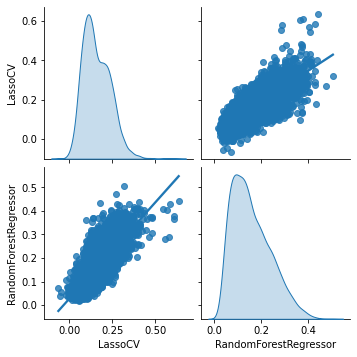

In [227]:
results_yc = evaluate_models(models, y=y_c)
generate_report(results_yc)

In [228]:
group_means_yc = compute_group_means_for_results(results_yc)

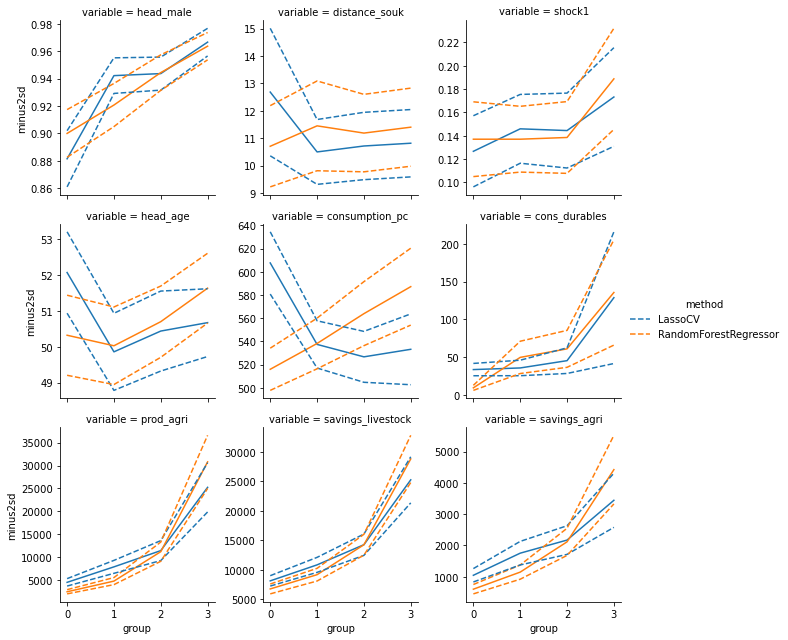

In [229]:
g = sns.FacetGrid(group_means_yc, col="variable", col_wrap=3, hue="method", sharey=False)
g.map(plt.plot, "group", "mean")
g.map(plt.plot, "group", "plus2sd", ls="--")
g.map(plt.plot, "group", "minus2sd", ls="--")
g.add_legend();

#### Amount borrowed

Correlation in median CATE:


,LassoCV,RandomForestRegressor
LassoCV,1.000000,0.668479
RandomForestRegressor,0.668479,1.000000




Best linear projection of CATE


LassoCV  RandomForestRegressor
blp 0  549.294316             566.633529
    1    0.207210               0.716093
se  0  143.382358             124.024021
    1    0.277354               0.253722



Group average treatment effects:


LassoCV  RandomForestRegressor
gate 0  202.443062              26.350261
     1  324.931204             287.017630
     2  384.530152             677.024222
     3  957.588633            1361.715402
se   0  127.668385             218.795102
     1  145.780177             123.843307
     2  191.972810             154.117558
     3  291.084466             329.186287

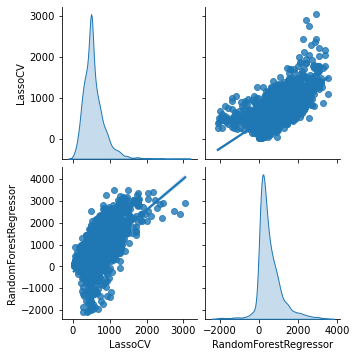

In [230]:
results_yb = evaluate_models(models, y=y_b)
generate_report(results_yb)

In [231]:
group_means_yb = compute_group_means_for_results(results_yb)

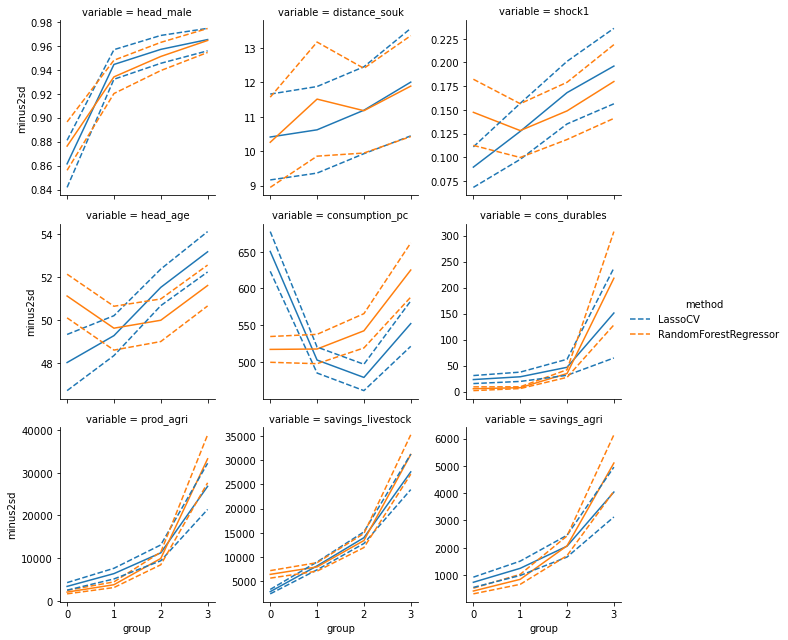

In [232]:
g = sns.FacetGrid(group_means_yb, col="variable", col_wrap=3, hue="method", sharey=False)
g.map(plt.plot, "group", "mean")
g.map(plt.plot, "group", "plus2sd", ls="--")
g.map(plt.plot, "group", "minus2sd", ls="--")
g.add_legend();

### Total profits

Correlation in median CATE:


,LassoCV,RandomForestRegressor
LassoCV,1.000000,0.288135
RandomForestRegressor,0.288135,1.000000




Best linear projection of CATE


LassoCV  RandomForestRegressor
blp 0 -4.079546            -498.873752
    1  0.177625               0.510189
se  0  3.364526            1289.753335
    1  0.305896               0.519415



Group average treatment effects:


LassoCV  RandomForestRegressor
gate 0 -15.581092           -4275.030566
     1  -0.800143            -129.471181
     2  -0.023008             105.407551
     3  -2.466999            1935.684096
se   0  10.454017            3606.823659
     1   2.903241             468.700057
     2   3.483316             400.378969
     3   6.853508            3816.234032

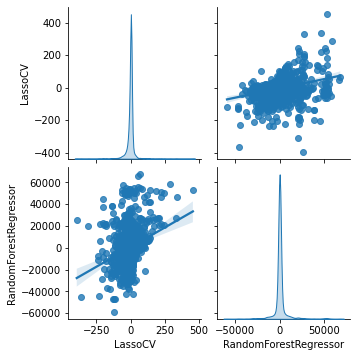

In [233]:
results_yp = evaluate_models(models, y=y_p)
generate_report(results_yp)

In [234]:
group_means_yp = compute_group_means_for_results(results_yp)

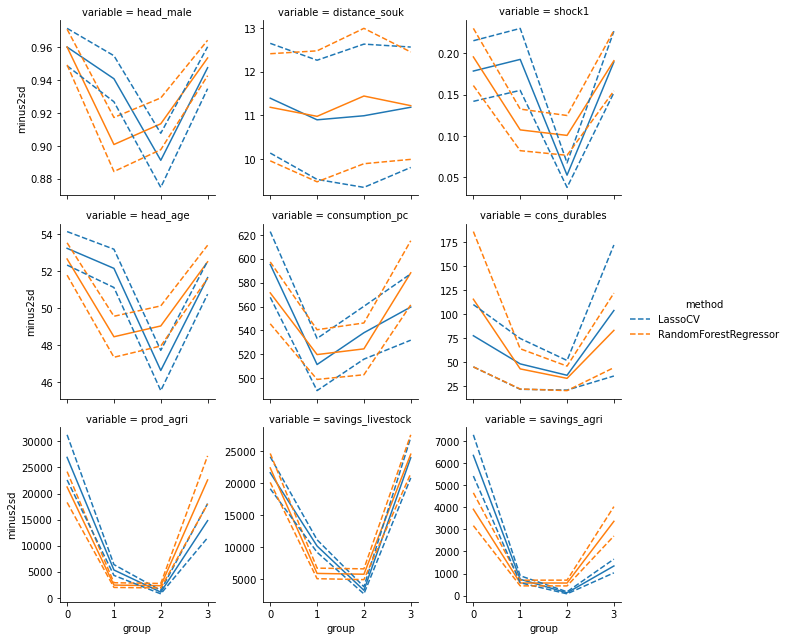

In [235]:
g = sns.FacetGrid(group_means_yp, col="variable", col_wrap=3, hue="method", sharey=False)
g.map(plt.plot, "group", "mean")
g.map(plt.plot, "group", "plus2sd", ls="--")
g.map(plt.plot, "group", "minus2sd", ls="--")
g.add_legend();